Imports

In [1]:
import uproot
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from pathlib import Path


Gaussian MATH Function

In [2]:
# Gaussian function definition
# ROOT 3201 - Joseph (8.5 MeV Neutrons) - Neutron breakup 
# ROOT 3214 - EJ3 (5 MeV Neutrons) - Bad PSD 

def gaussian(x, amp, mean, std_dev):
    return amp * np.exp(-((x - mean)**2) / (2 * std_dev**2))
    
# Gaussian definition with a significant backgorund contribution
def gaussian_with_bg(x, amp, mean, std_dev, bg):
    return amp * np.exp(-((x - mean)**2) / (2 * std_dev**2)) + bg
    
# Sum of two Gaussians (used for curve fitting)
def double_gaussian(x, a1, mu1, sigma1, a2, mu2, sigma2):
    return (a1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) +
            a2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)))

# Normalize a fitted gaussian 
def normalize_gaussian(amp, mean, std_dev):
    area = amp * std_dev * np.sqrt(2 * np.pi)
    norm_amp = 1 / (std_dev * np.sqrt(2 * np.pi))
    return norm_amp, mean, std_dev #returns new normalzied parameters 

Calibrations

In [3]:
#Redefinition functions
#These are for 8ADC DAQ, need to update to Mesytec

#Energy calibrations
def ecal(ea_array, route_number):
    if route_number == 4:  # Ne-213 
        return ea_array * 0.001455 - 0.20
    elif route_number == 8:  # Stilbene
        return ea_array * 0.004372 - 0.20

#Tof calibrations
def tcal(tof_array, route_number): 
    return tof_array * -0.22 + 932.53

Parameters

In [4]:
ROOT_FILE_PATH = r"C:\Users\jackb\OneDrive - Ohio University\Desktop\VS Code\Root\INPP Fall 2025\run3200.root"

ROUTE  = 4    # 4 = NE-213, 8 = Stilbene
ELOW   = 0.2  # MeVee low cutoff 
EHIGH  = 4.0  # MeVee high cutoff

Load Data

In [5]:
# Extracts parameters from the root file and determines possible routes
with uproot.open(ROOT_FILE_PATH) as file:
    tree = file["T;1"]
    ea_values    = tree["ea"].array()
    psd_values   = tree["psd"].array()
    route_values = tree["route"].array()
    tof_values   = tree["tof"].array()
    unique_routes = [4, 8]  # Known routes for this specific file

route_names = {4: "NE-213", 8: "Stilbene"}

# Apply route mask and calibrations
mask = route_values == ROUTE
ea_route = ecal(ea_values[mask], ROUTE)
psd_route = psd_values[mask]
tof_route = tof_values[mask]

ea_arr = np.array(ea_route)
psd_arr = np.array(psd_route)

Energy Histogram (Plot)

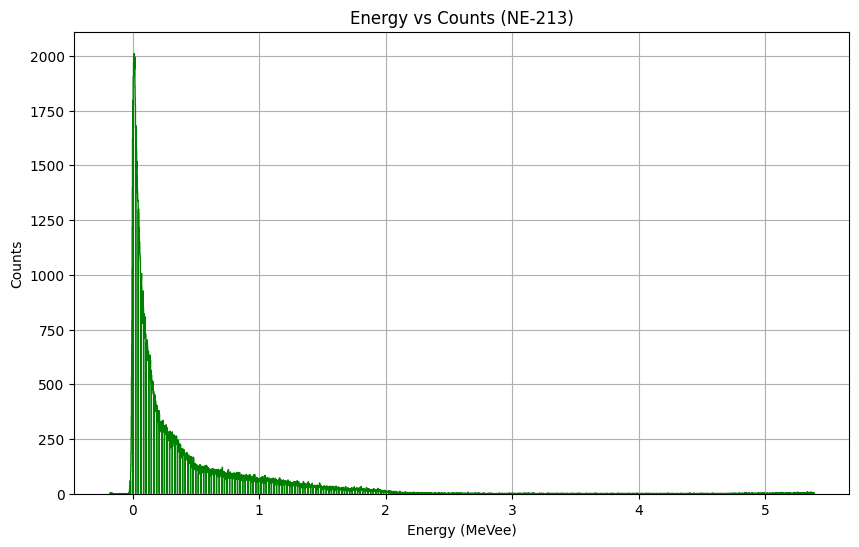

In [6]:
plt.figure(figsize=(10, 6))
plt.hist(ea_arr, bins=4096, histtype='step', color='green')
plt.title(f"Energy vs Counts ({route_names[ROUTE]})")
plt.xlabel("Energy (MeVee)")
plt.ylabel("Counts")
plt.grid(True)
plt.show()

ToF Histogram (Plot)

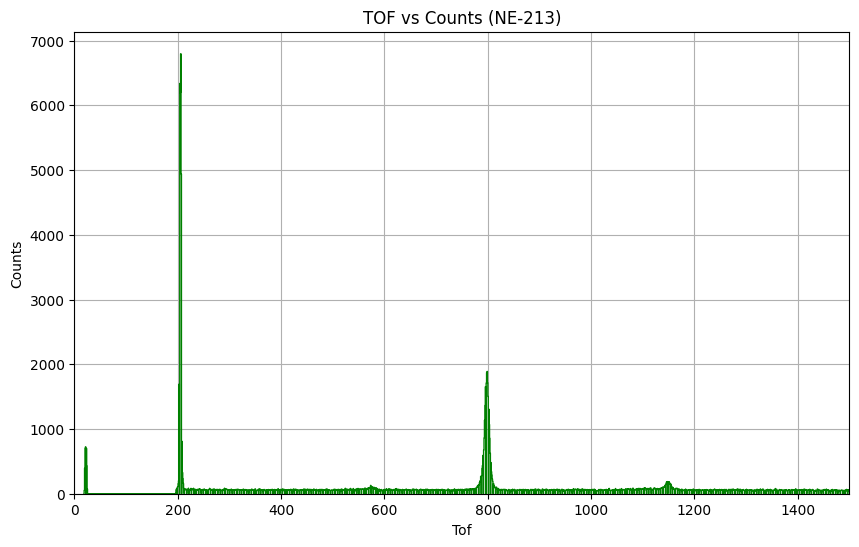

In [7]:
plt.figure(figsize=(10, 6))
plt.hist(tof_route, bins=4096, histtype='step', color='green')
plt.xlim(0, 1500)
plt.title(f"TOF vs Counts ({route_names[ROUTE]})")
plt.xlabel("Tof")
plt.ylabel("Counts")
plt.grid(True)
#tof_route = tcal(tof_route, ROUTE)  # Uncomment to apply TOF calibration
plt.show()

ToF Two Single Gaussian's Parameter Esimation (Plot)

Measured background: 55.29 counts/channel
Fit parameters:
   Gaussian 1: amplitude=1781.26, mean=798.80, sigma=4.91
   Gaussian 2: amplitude=108.78, mean=1149.31, sigma=5.18, bg=69.77


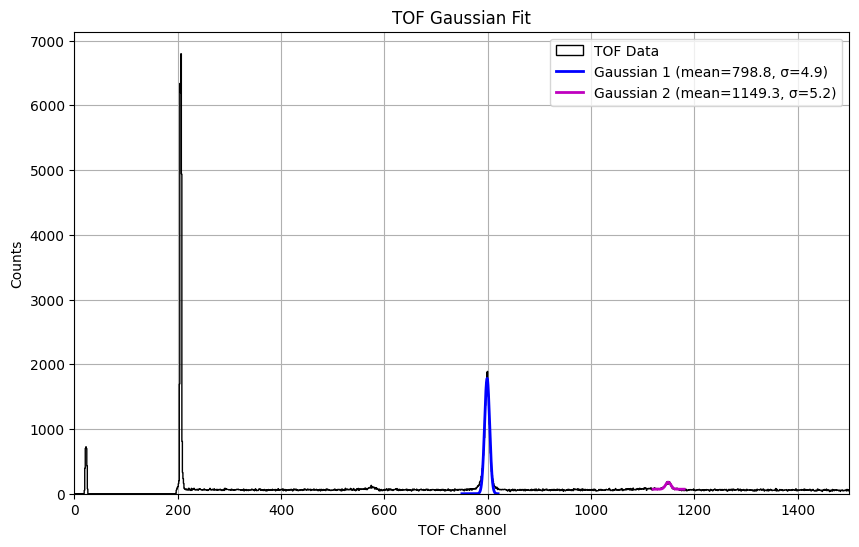

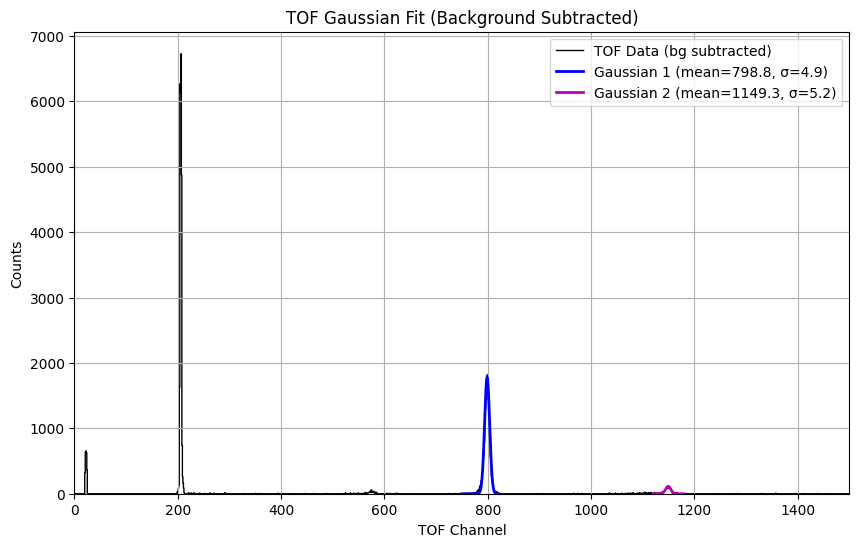

In [8]:
from scipy.optimize import curve_fit

# Find background with width before gammas (right side) about the same number of channels as fitting range
# Parameters guess
MAX1, CENT1, SIGMA1 = 1800, 780, 10
MAX2, CENT2, SIGMA2 = 180, 1150, 5

# Background estimation range - far right of spectrum, similar width to fitting ranges
BG_RANGE = [1335, 1400]

# Range used to guide fitting and plot Gaussians over
FIT_RANGE1 = [750, 820]
FIT_RANGE2 = [1120, 1180]

# Data to use
tof_arr = np.asarray(tof_route)

# Extract counts and bin arrays for fitting (full spectrum)
counts, bin_edges = np.histogram(tof_arr, bins=4096, range=(0, 4096))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Measure background from flat far right region
mask_bg = (bin_centers >= BG_RANGE[0]) & (bin_centers <= BG_RANGE[1])
bg = np.mean(counts[mask_bg])
print(f"Measured background: {bg:.2f} counts/channel")

# Isolate each peak in its own window for independent fitting
mask1 = (bin_centers >= FIT_RANGE1[0]) & (bin_centers <= FIT_RANGE1[1])
mask2 = (bin_centers >= FIT_RANGE2[0]) & (bin_centers <= FIT_RANGE2[1])

try:
    # Fit each Gaussian independently on its own masked region
    tof_fitted_params_1, _ = curve_fit(gaussian, bin_centers[mask1], counts[mask1], p0=[MAX1, CENT1, SIGMA1])
    tof_fitted_params_2, _ = curve_fit(gaussian_with_bg, bin_centers[mask2], counts[mask2], p0=[MAX2, CENT2, SIGMA2, bg])

    # Background subtracted counts (clipped at 0 to avoid negatives)
    counts_bg_sub = np.clip(counts - tof_fitted_params_2[3], 0, None)

    # Print fitted parameters
    print(f"Fit parameters:")
    print(f"   Gaussian 1: amplitude={tof_fitted_params_1[0]:.2f}, mean={tof_fitted_params_1[1]:.2f}, sigma={tof_fitted_params_1[2]:.2f}")
    print(f"   Gaussian 2: amplitude={tof_fitted_params_2[0]:.2f}, mean={tof_fitted_params_2[1]:.2f}, sigma={tof_fitted_params_2[2]:.2f}, bg={tof_fitted_params_2[3]:.2f}")

    # Plot fit ranges
    x_fit1 = np.linspace(FIT_RANGE1[0], FIT_RANGE1[1], 1000)
    x_fit2 = np.linspace(FIT_RANGE2[0], FIT_RANGE2[1], 1000)

    # Plot 1: Full spectrum with background included in Gaussian 2
    plt.figure(figsize=(10, 6))
    plt.hist(tof_arr, bins=4096, range=(0, 4096), histtype='step', color='black', label='TOF Data')
    plt.plot(x_fit1, gaussian(x_fit1, *tof_fitted_params_1), 'b', linewidth=2, label=f'Gaussian 1 (mean={tof_fitted_params_1[1]:.1f}, σ={tof_fitted_params_1[2]:.1f})')
    plt.plot(x_fit2, gaussian(x_fit2, *tof_fitted_params_2[:3]) + tof_fitted_params_2[3], 'm', linewidth=2, label=f'Gaussian 2 (mean={tof_fitted_params_2[1]:.1f}, σ={tof_fitted_params_2[2]:.1f})')
    plt.title("TOF Gaussian Fit")
    plt.xlabel("TOF Channel")
    plt.ylabel("Counts")
    plt.xlim(0, 1500)
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot 2: Background subtracted counts with pure Gaussian 2
    plt.figure(figsize=(10, 6))
    plt.stairs(counts_bg_sub, bin_edges, color='black', label='TOF Data (bg subtracted)')
    plt.plot(x_fit1, gaussian(x_fit1, *tof_fitted_params_1), 'b', linewidth=2, label=f'Gaussian 1 (mean={tof_fitted_params_1[1]:.1f}, σ={tof_fitted_params_1[2]:.1f})')
    plt.plot(x_fit2, gaussian(x_fit2, *tof_fitted_params_2[:3]), 'm', linewidth=2, label=f'Gaussian 2 (mean={tof_fitted_params_2[1]:.1f}, σ={tof_fitted_params_2[2]:.1f})')
    plt.title("TOF Gaussian Fit (Background Subtracted)")
    plt.xlabel("TOF Channel")
    plt.ylabel("Counts")
    plt.xlim(0, 1500)
    plt.legend()
    plt.grid(True)
    plt.show()

except RuntimeError:
    print("Fit failed. Adjust parameters at the top of the cell.")

PSD Histogram

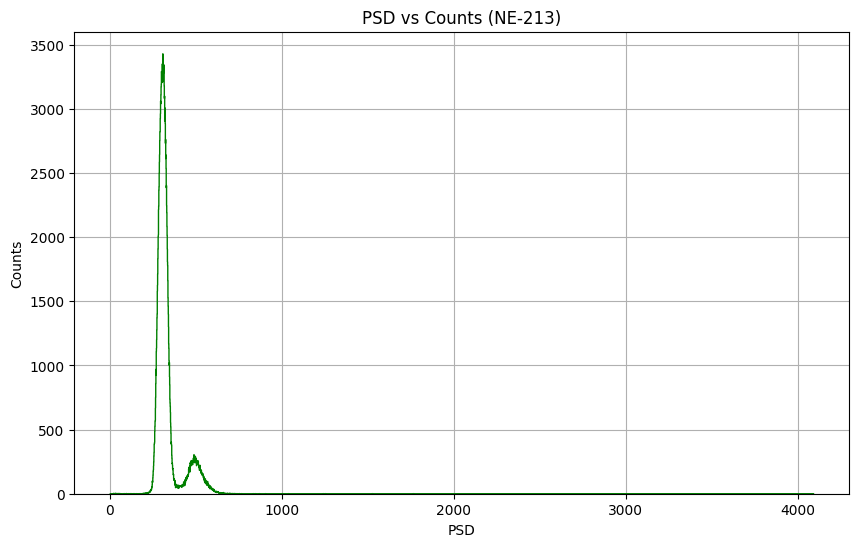

In [9]:
# Plot PSD histogram
x = np.linspace(0, 4096, 4096)

plt.figure(figsize=(10, 6))
plt.hist(psd_arr, bins=4096, range=(0, 4096), histtype='step', color='green')
plt.title(f"PSD vs Counts ({route_names[ROUTE]})")
plt.xlabel("PSD")
plt.ylabel("Counts")
plt.grid(True)
plt.show()

PSD Double Gaussian Parameter Esimation (Plot)

Fit parameters [Range 200–800]:
  Gaussian 1: amplitude=3411.73, mean=308.74, sigma=24.36
  Gaussian 2: amplitude=252.96, mean=496.61, sigma=45.29


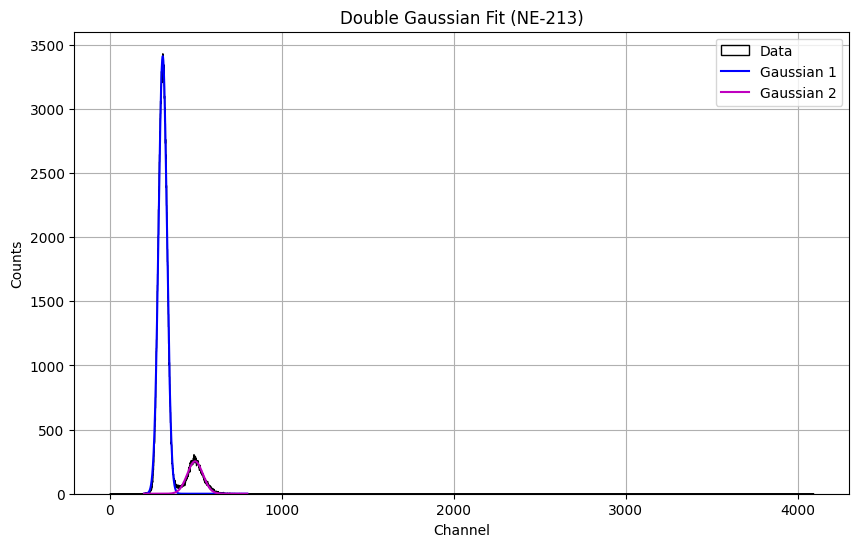

In [10]:
from scipy.optimize import curve_fit

# Data to use
DATA = psd_arr
FIT_RANGE = [200, 800]

# Parameters guess
MAX1 = 3411
CENT1 = 309
SIGMA1 = 24
MAX2 = 253
CENT2 = 497
SIGMA2 = 45

XLABEL = "Channel"
TITLE = f"Double Gaussian Fit ({route_names[ROUTE]})"

# Apply range filter
fit_data = np.asarray(DATA)
fit_data = fit_data[(fit_data >= FIT_RANGE[0]) & (fit_data <= FIT_RANGE[1])]

# Extract counts and bin arrays for fitting
counts, bin_edges = np.histogram(fit_data, bins=4096, range=(0, 4096))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

initial_guess = [
    MAX1, CENT1, SIGMA1,   # First peak: amplitude, mean, sigma
    MAX2, CENT2, SIGMA2    # Second peak: amplitude, mean, sigma
]

try:
    # Use curve_fit to fit double gaussian to data
    fitted_params_psd, _ = curve_fit(double_gaussian, bin_centers, counts, p0=initial_guess)

    # Print fit parameters
    print(f"Fit parameters [Range {FIT_RANGE[0]}–{FIT_RANGE[1]}]:")
    print(f"  Gaussian 1: amplitude={fitted_params_psd[0]:.2f}, mean={fitted_params_psd[1]:.2f}, sigma={fitted_params_psd[2]:.2f}")
    print(f"  Gaussian 2: amplitude={fitted_params_psd[3]:.2f}, mean={fitted_params_psd[4]:.2f}, sigma={fitted_params_psd[5]:.2f}")

    # Plot histogram and fit
    plt.figure(figsize=(10, 6))
    plt.hist(fit_data, bins=4096, range=(0, 4096), histtype='step', color='black', label='Data')
    x_fit = np.linspace(FIT_RANGE[0], FIT_RANGE[1], 1000)

    # Individual Gaussians
    g1 = fitted_params_psd[0] * np.exp(-(x_fit - fitted_params_psd[1])**2 / (2 * fitted_params_psd[2]**2))
    g2 = fitted_params_psd[3] * np.exp(-(x_fit - fitted_params_psd[4])**2 / (2 * fitted_params_psd[5]**2))
    plt.plot(x_fit, g1, 'b', label='Gaussian 1')
    plt.plot(x_fit, g2, 'm', label='Gaussian 2')
    plt.title(TITLE)
    plt.xlabel(XLABEL)
    plt.ylabel("Counts")
    plt.legend()
    plt.grid(True)
    plt.show()

except RuntimeError:
    print("Fit failed. Try adjusting initial guesses or fitting range.")

Energy vs PSD Side by Side (Plot)

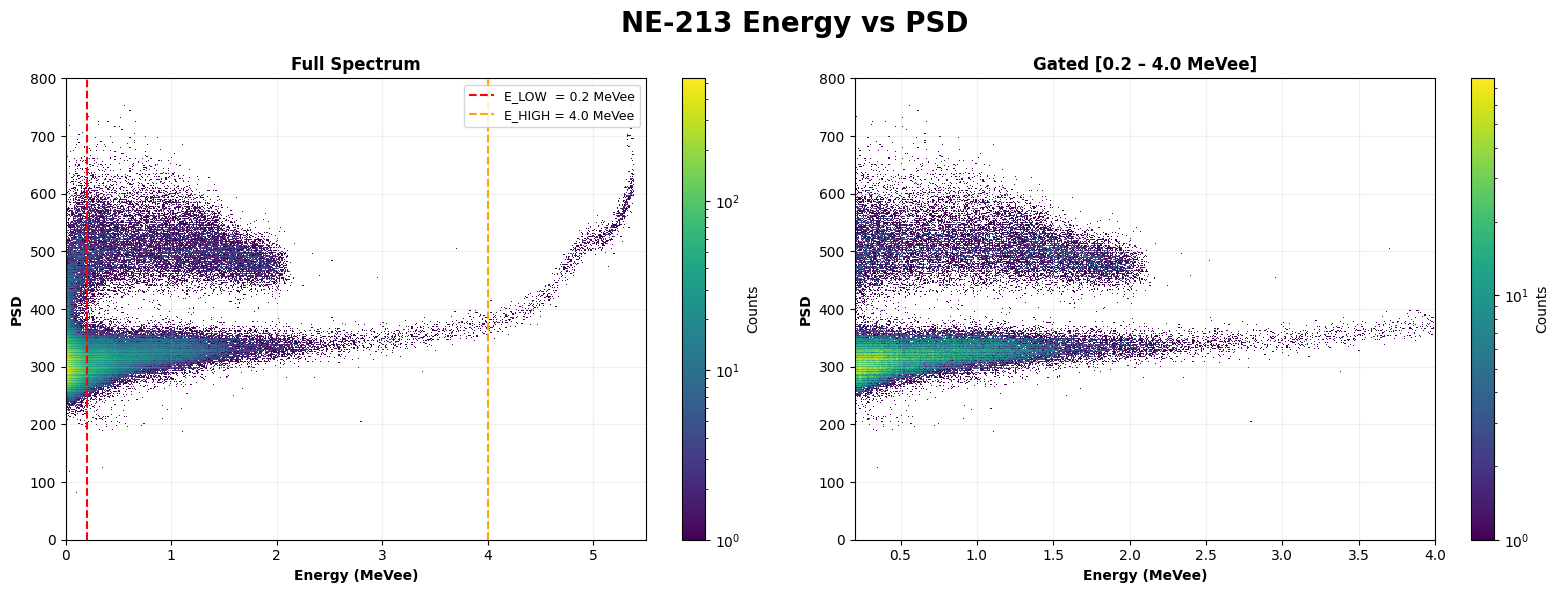

In [11]:
gate = (ea_arr > ELOW) & (ea_arr < EHIGH)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'{route_names[ROUTE]} Energy vs PSD', fontsize=20, weight='bold')

# Left: full range, log color scale
h1 = axes[0].hist2d(ea_arr, psd_arr,
                    bins=[500, 500],
                    range=[[0, 5.5], [0, 800]],
                    cmap='viridis',
                    norm=mcolors.LogNorm())
plt.colorbar(h1[3], ax=axes[0], label='Counts')
line1 = axes[0].axvline(ELOW,  color='red',    linestyle='--', linewidth=1.5, label='E_LOW  = ' + str(ELOW)  + ' MeVee')
line2 = axes[0].axvline(EHIGH, color='orange', linestyle='--', linewidth=1.5, label='E_HIGH = ' + str(EHIGH) + ' MeVee')
axes[0].set_xlabel("Energy (MeVee)", weight="bold")
axes[0].set_ylabel("PSD", weight="bold")
axes[0].set_title("Full Spectrum", weight="bold")
axes[0].legend(handles=[line1, line2], fontsize=9, loc='upper right')  # Fixed location avoids slow "best" search
axes[0].grid(True, alpha=0.2)

# Right: gated region only
h2 = axes[1].hist2d(ea_arr[gate], psd_arr[gate],
                    bins=[500, 500],
                    range=[[ELOW, EHIGH], [0, 800]],
                    cmap='viridis',
                    norm=mcolors.LogNorm())
plt.colorbar(h2[3], ax=axes[1], label='Counts')
axes[1].set_xlabel("Energy (MeVee)", weight="bold")
axes[1].set_ylabel("PSD", weight="bold")
axes[1].set_title("Gated [" + str(ELOW) + " – " + str(EHIGH) + " MeVee]", weight="bold")
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Enerygy vs PSD Full (Plot)

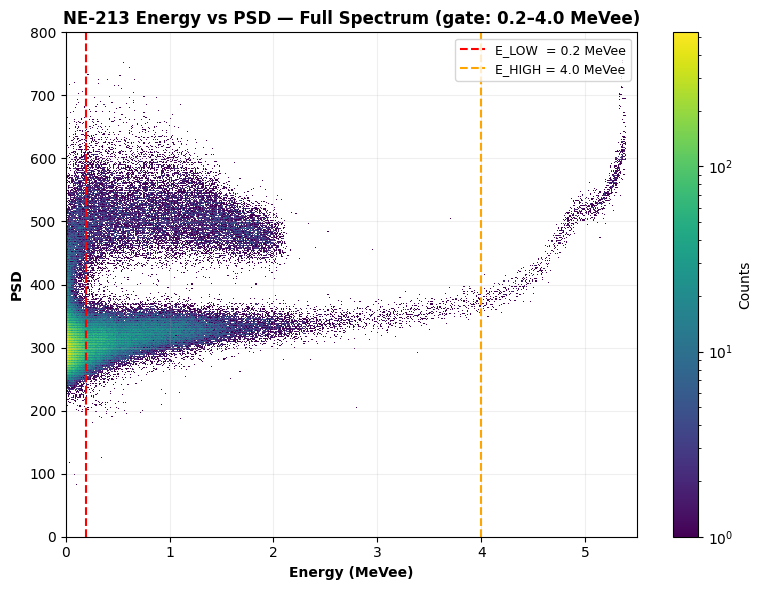

In [12]:
gate = (ea_arr > ELOW) & (ea_arr < EHIGH)
fig, ax = plt.subplots(figsize=(8, 6))
h = ax.hist2d(ea_arr, psd_arr,
              bins=[500, 500],
              range=[[0, 5.5], [0, 800]],
              cmap='viridis',
              norm=mcolors.LogNorm())
plt.colorbar(h[3], ax=ax, label='Counts')
line1 = ax.axvline(ELOW,  color='red',    linestyle='--', linewidth=1.5, label=f'E_LOW  = {ELOW} MeVee')
line2 = ax.axvline(EHIGH, color='orange', linestyle='--', linewidth=1.5, label=f'E_HIGH = {EHIGH} MeVee')
ax.set_xlabel("Energy (MeVee)", weight="bold")
ax.set_ylabel("PSD", weight="bold")
ax.set_title(f"{route_names[ROUTE]} Energy vs PSD — Full Spectrum (gate: {ELOW}–{EHIGH} MeVee)", weight="bold")
ax.legend(handles=[line1, line2], fontsize=9, loc='upper right')  # Fixed location avoids slow "best" search
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Enerygy vs PSD Gated (Plot)

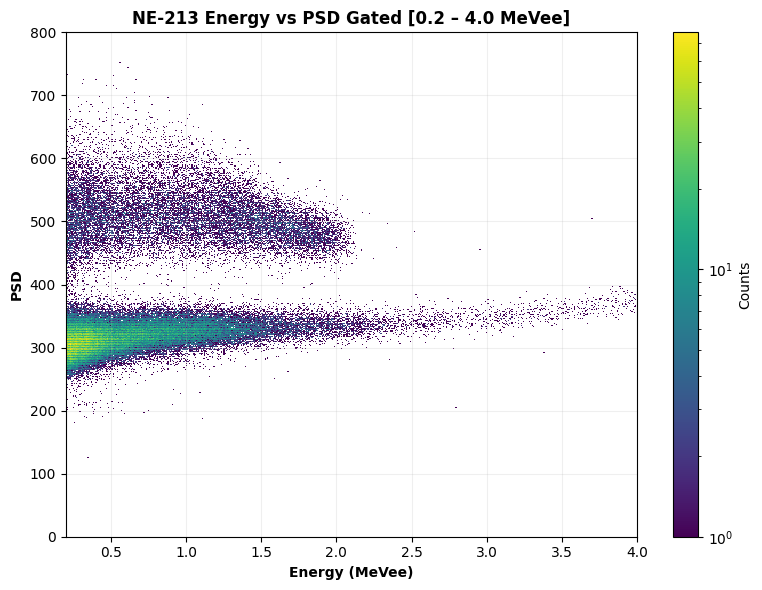

In [13]:
gate = (ea_arr > ELOW) & (ea_arr < EHIGH)

fig, ax = plt.subplots(figsize=(8, 6))
h = ax.hist2d(ea_arr[gate], psd_arr[gate],
              bins=[500, 500],
              range=[[ELOW, EHIGH], [0, 800]],
              cmap='viridis',
              norm=mcolors.LogNorm())
plt.colorbar(h[3], ax=ax, label='Counts')
ax.set_xlabel("Energy (MeVee)", weight="bold")
ax.set_ylabel("PSD", weight="bold")
ax.set_title(f"{route_names[ROUTE]} Energy vs PSD Gated [{ELOW} – {EHIGH} MeVee]", weight="bold")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

Normalzied gaussians PSD + ToF (Plot)

Normalized TOF parameters:
  Gaussian 1: amplitude=0.081328, mean=798.80, sigma=4.91
  Gaussian 2: amplitude=0.076983, mean=1149.31, sigma=5.18

Normalized PSD parameters:
  Gaussian 1: amplitude=0.016380, mean=308.74, sigma=24.36
  Gaussian 2: amplitude=0.008810, mean=496.61, sigma=45.29


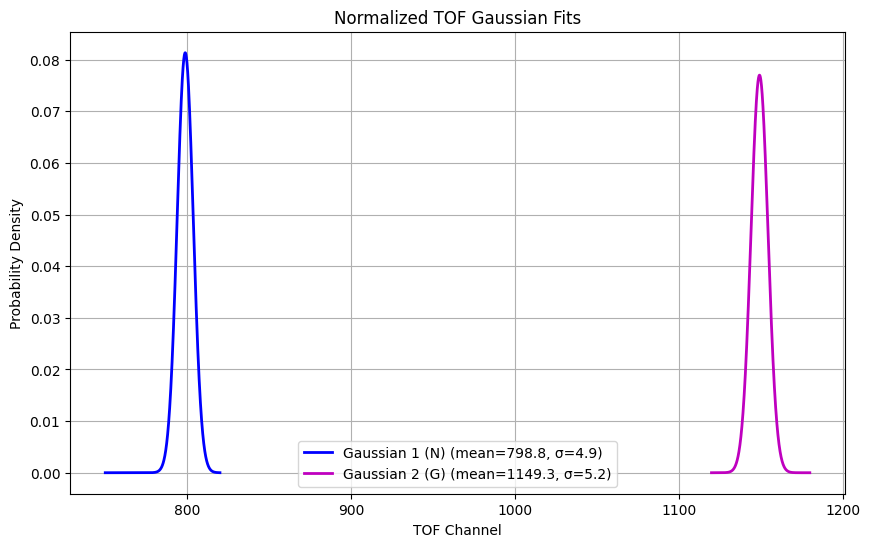

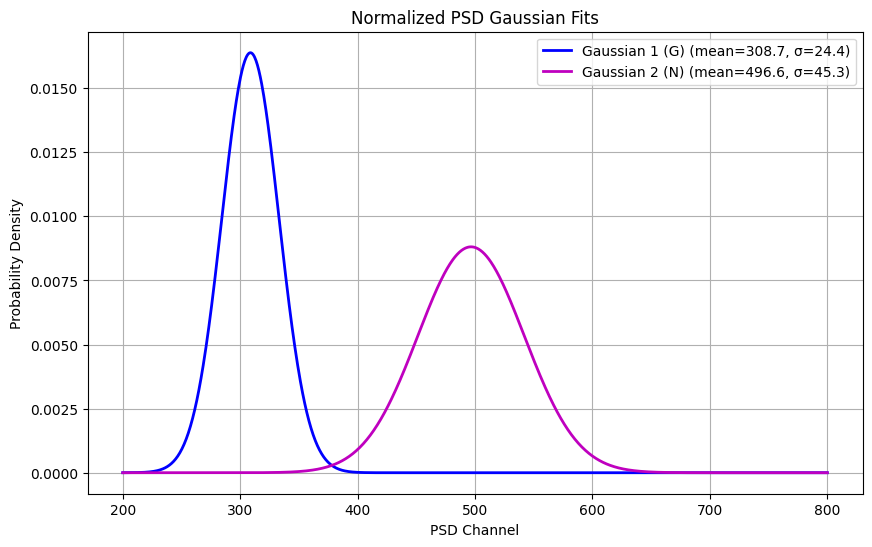

In [14]:
# Normalize fitted Gaussian parameters (TOF)
tof_neutron_norm_params = normalize_gaussian(*tof_fitted_params_1)
tof_gamma_norm_params = normalize_gaussian(*tof_fitted_params_2[:3])

# Normalize fitted Gaussian parameters (PSD)
psd_gamma_norm_params = normalize_gaussian(*fitted_params_psd[0:3])
psd_neutron_norm_params = normalize_gaussian(*fitted_params_psd[3:6])

# Print normalized TOF parameters
print(f"Normalized TOF parameters:")
print(f"  Gaussian 1: amplitude={tof_neutron_norm_params[0]:.6f}, mean={tof_neutron_norm_params[1]:.2f}, sigma={tof_neutron_norm_params[2]:.2f}")
print(f"  Gaussian 2: amplitude={tof_gamma_norm_params[0]:.6f}, mean={tof_gamma_norm_params[1]:.2f}, sigma={tof_gamma_norm_params[2]:.2f}")

# Print normalized PSD parameters
print(f"\nNormalized PSD parameters:")
print(f"  Gaussian 1: amplitude={psd_gamma_norm_params[0]:.6f}, mean={psd_gamma_norm_params[1]:.2f}, sigma={psd_gamma_norm_params[2]:.2f}")
print(f"  Gaussian 2: amplitude={psd_neutron_norm_params[0]:.6f}, mean={psd_neutron_norm_params[1]:.2f}, sigma={psd_neutron_norm_params[2]:.2f}")

# Plot normalized TOF Gaussians
plt.figure(figsize=(10, 6))
x_fit_tof_1 = np.linspace(FIT_RANGE1[0], FIT_RANGE1[1], 1000)
x_fit_tof_2 = np.linspace(FIT_RANGE2[0], FIT_RANGE2[1], 1000)
plt.plot(x_fit_tof_1, gaussian(x_fit_tof_1, *tof_neutron_norm_params), 'b', linewidth=2, label=f'Gaussian 1 (N) (mean={tof_neutron_norm_params[1]:.1f}, σ={tof_neutron_norm_params[2]:.1f})')
plt.plot(x_fit_tof_2, gaussian(x_fit_tof_2, *tof_gamma_norm_params), 'm', linewidth=2, label=f'Gaussian 2 (G) (mean={tof_gamma_norm_params[1]:.1f}, σ={tof_gamma_norm_params[2]:.1f})')
plt.title("Normalized TOF Gaussian Fits")
plt.xlabel("TOF Channel")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

# Plot normalized PSD Gaussians
plt.figure(figsize=(10, 6))
x_fit_psd = np.linspace(FIT_RANGE[0], FIT_RANGE[1], 1000)
plt.plot(x_fit_psd, gaussian(x_fit_psd, *psd_gamma_norm_params), 'b', linewidth=2, label=f'Gaussian 1 (G) (mean={psd_gamma_norm_params[1]:.1f}, σ={psd_gamma_norm_params[2]:.1f})')
plt.plot(x_fit_psd, gaussian(x_fit_psd, *psd_neutron_norm_params), 'm', linewidth=2, label=f'Gaussian 2 (N) (mean={psd_neutron_norm_params[1]:.1f}, σ={psd_neutron_norm_params[2]:.1f})')
plt.title("Normalized PSD Gaussian Fits")
plt.xlabel("PSD Channel")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True)
plt.show()

Gated ToF using PSD Gamma and Neutron Peaks (plot)

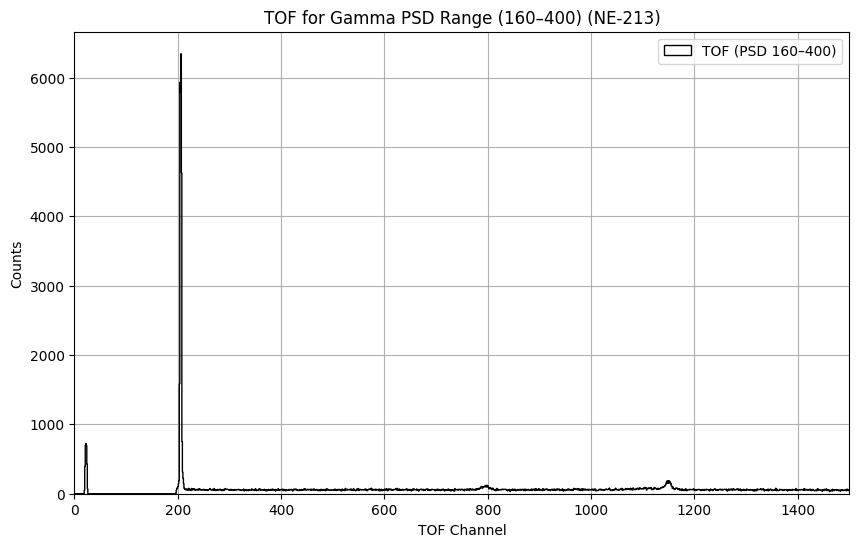

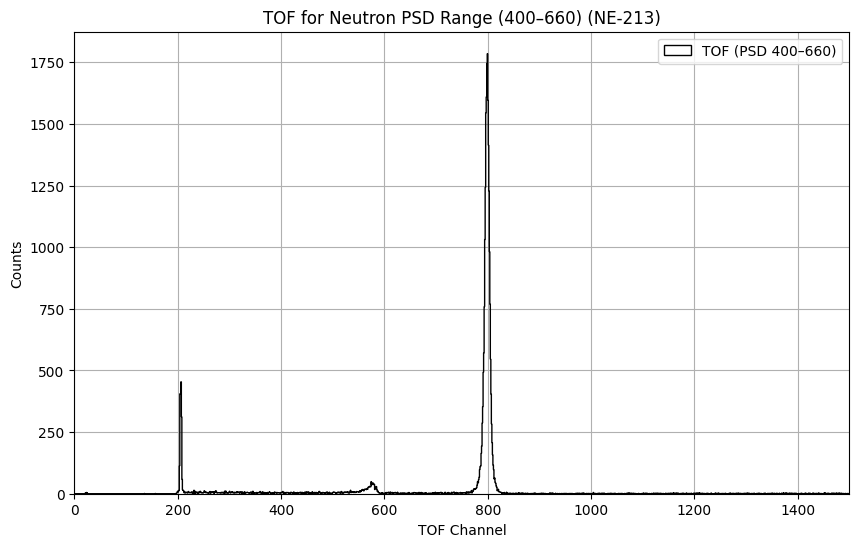

In [15]:
# Mask TOF data to only events where PSD falls in gamma peak range (160-400)
psd_gamma_mask = (psd_arr >= 160) & (psd_arr <= 400)
tof_gamma = tof_route[psd_gamma_mask]

# Mask TOF data to only events where PSD falls in neutron peak range (400-660)
psd_neutron_mask = (psd_arr >= 400) & (psd_arr <= 660)
tof_neutron = tof_route[psd_neutron_mask]

# Plot TOF for gamma PSD range only
plt.figure(figsize=(10, 6))
plt.hist(tof_gamma, bins=4096, range=(0, 4096), histtype='step', color='black', label='TOF (PSD 160–400)')
plt.title(f"TOF for Gamma PSD Range (160–400) ({route_names[ROUTE]})")
plt.xlabel("TOF Channel")
plt.ylabel("Counts")
plt.xlim(0, 1500)
plt.grid(True)
plt.legend()
plt.show()

# Plot TOF for neutron PSD range only
plt.figure(figsize=(10, 6))
plt.hist(tof_neutron, bins=4096, range=(0, 4096), histtype='step', color='black', label='TOF (PSD 400–660)')
plt.title(f"TOF for Neutron PSD Range (400–660) ({route_names[ROUTE]})")
plt.xlabel("TOF Channel")
plt.ylabel("Counts")
plt.xlim(0, 1500)
plt.grid(True)
plt.legend()
plt.show()

Bayesian Formula

ROUTE 4: NE-213
Sigma Scaling Factor: 1
Total Gated Events:   102,454
Validated Neutrons:   19728.74
Validated Gammas:     3109.14
Statistical Outliers: 79616.12
Integrity Check: 0.0000


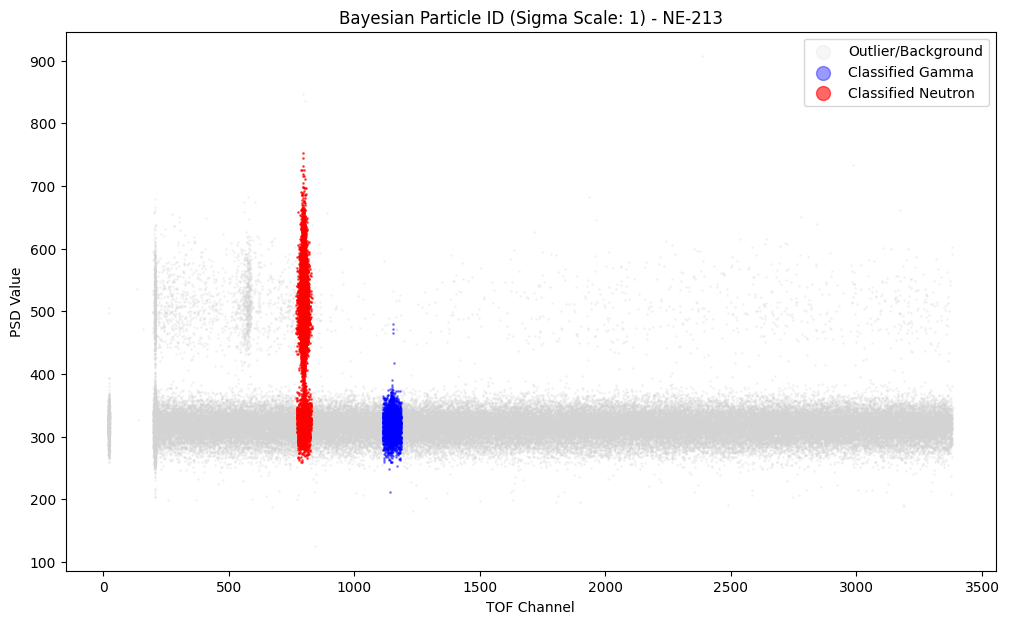

In [16]:
# sigma_scale = 2.0 or 2.5 is recommended to capture the long tails 
# This reduces the outlier count
sigma_scale = 1
t_data = np.asarray(tof_route, dtype=np.float64)
p_data = np.asarray(psd_arr, dtype=np.float64)


# TOF Likelihoods
S_tof_g = gaussian(t_data, tof_gamma_norm_params[0], tof_gamma_norm_params[1], tof_gamma_norm_params[2] * sigma_scale)
S_tof_n = gaussian(t_data, tof_neutron_norm_params[0], tof_neutron_norm_params[1], tof_neutron_norm_params[2] * sigma_scale)

# PSD Likelihoods
S_psd_g = gaussian(p_data, psd_gamma_norm_params[0], psd_gamma_norm_params[1], psd_gamma_norm_params[2] * sigma_scale)
S_psd_n = gaussian(p_data, psd_neutron_norm_params[0], psd_neutron_norm_params[1], psd_neutron_norm_params[2] * sigma_scale)


# Creating PRIOR using tof (area under gaussians) - estimate yield of each particle 
# tof_fitted_params_1 = [amplitude, mean, sigma]
# tof_fitted_params_2 = [amplitude, mean, sigma, bg]
area_g = tof_fitted_params_1[0] * tof_fitted_params_1[2] * np.sqrt(2 * np.pi)
area_n = tof_fitted_params_2[0] * tof_fitted_params_2[2] * np.sqrt(2 * np.pi)


# Joint Probabilities (score = prob from tof gaussian x prob from psd gaussian x prob from prior)
Score_G = (S_tof_g * S_psd_g) * area_g
Score_N = (S_tof_n * S_psd_n) * area_n

# Floor probability handles events that fall outside both peaks (outliers)
# If Prob of gamma and neutron is smaller than the "floor" labeled as an outlier
floor_prob = 1e-10 
total_evidence = Score_G + Score_N + floor_prob

#This is effectively normalzing the score probability 
prob_g = Score_G / total_evidence
prob_n = Score_N / total_evidence
prob_outlier = floor_prob / total_evidence

# sum each classifier (gated) to get an expected value 
# Gated with 2D energy vs psd
n_count = np.sum(prob_n[gate])
g_count = np.sum(prob_g[gate])
outlier_count = np.sum(prob_outlier[gate])

# Display Results
print(f"ROUTE {ROUTE}: {route_names[ROUTE]}")
print(f"Sigma Scaling Factor: {sigma_scale}")
print(f"Total Gated Events:   {np.sum(gate):,}")
print(f"Validated Neutrons:   {n_count:.2f}")
print(f"Validated Gammas:     {g_count:.2f}")
print(f"Statistical Outliers: {outlier_count:.2f}")

# Integrity Check: shpuld be 0.0000 because its all events - all events 
integrity = np.sum(gate) - (n_count + g_count + outlier_count)
print(f"Integrity Check: {integrity:.4f}")

# Visualization 
is_neutron = (prob_n > 0.5) & gate
is_gamma = (prob_g > 0.5) & gate
is_outlier = (prob_outlier > 0.5) & gate

plt.figure(figsize=(12, 7))
plt.scatter(t_data[is_outlier], p_data[is_outlier], s=1, color='lightgray', alpha=0.2, label='Outlier/Background')
plt.scatter(t_data[is_gamma], p_data[is_gamma], s=1, color='blue', alpha=0.4, label='Classified Gamma')
plt.scatter(t_data[is_neutron], p_data[is_neutron], s=1, color='red', alpha=0.6, label='Classified Neutron')

plt.title(f"Bayesian Particle ID (Sigma Scale: {sigma_scale}) - {route_names[ROUTE]}")
plt.xlabel("TOF Channel")
plt.ylabel("PSD Value")
plt.legend(markerscale=10)
plt.show()


Plot Classified events 

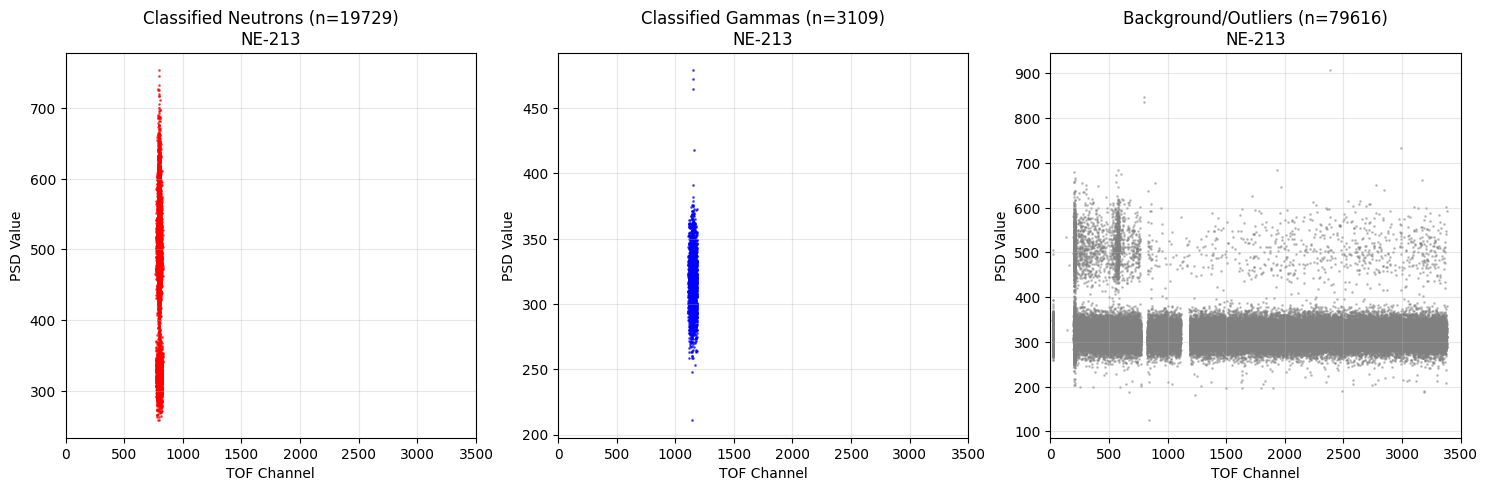

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax in axes:
    ax.set_xlim(0, 3500)
    
# Plot 1: Neutrons
axes[0].scatter(t_data[is_neutron], p_data[is_neutron], s=1, color='red', alpha=0.6)
axes[0].set_title(f"Classified Neutrons (n={n_count:.0f})\n{route_names[ROUTE]}")
plt.xlim(0, 3500)
axes[0].set_xlabel("TOF Channel")
axes[0].set_ylabel("PSD Value")
axes[0].grid(True, alpha=0.3)

# Plot 2: Gammas
axes[1].scatter(t_data[is_gamma], p_data[is_gamma], s=1, color='blue', alpha=0.6)
axes[1].set_title(f"Classified Gammas (n={g_count:.0f})\n{route_names[ROUTE]}")
plt.xlim(0, 3500)
axes[1].set_xlabel("TOF Channel")
axes[1].set_ylabel("PSD Value")
axes[1].grid(True, alpha=0.3)

# Plot 3: Outliers/Background
axes[2].scatter(t_data[is_outlier], p_data[is_outlier], s=1, color='gray', alpha=0.4)
axes[2].set_title(f"Background/Outliers (n={outlier_count:.0f})\n{route_names[ROUTE]}")
plt.xlim(0, 3500)
axes[2].set_xlabel("TOF Channel")
axes[2].set_ylabel("PSD Value")
axes[2].grid(True, alpha=0.3)

plt.show()

Export File With Classifications 

In [18]:
# Set output to current working directory (same as JupyterLab file browser)
output_dir = Path.cwd()

# Export all data in one file with classification labels
all_data = pd.DataFrame({
    'TOF_Channel': t_data[gate],
    'PSD_Value': p_data[gate],
    'Prob_Neutron': prob_n[gate],
    'Prob_Gamma': prob_g[gate],
    'Prob_Outlier': prob_outlier[gate],
    'Classification': np.where(is_neutron[gate], 'Neutron',
                               np.where(is_gamma[gate], 'Gamma', 'Outlier'))
})

# Save to current directory
file_path = output_dir / f'all_classified_events_route{ROUTE}.csv'
all_data.to_csv(file_path, index=False)

print(f"File name: all_classified_events_route{ROUTE}.csv")
print(f"Full path: {file_path}")
print(f"Total events: {len(all_data):,}")

File name: all_classified_events_route4.csv
Full path: C:\Users\jackb\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\Scripts\all_classified_events_route4.csv
Total events: 102,454
